# Day 4 - Transition into LLM Model Based + Fine Tuning Frontier Model

In [1]:
import os
import json
from dotenv import load_dotenv
from huggingface_hub import login
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset, DatasetDict, concatenate_datasets, Value
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from openai import OpenAI
from litellm import completion
from tqdm.notebook import tqdm
from IPython.display import display, Markdown
from pricer.evaluator import evaluate

In [2]:
load_dotenv(override=True)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

In [3]:
openai = OpenAI(api_key=OPENAI_API_KEY)

In [4]:
ds = load_dataset("matthewyn/stocks")
train = ds["train"]
val = ds["validation"]
test = ds["test"]

In [5]:
display(Markdown(test[0]["Price History"]))

TREND: Bearish — the stock has been declining sharply, consistently below all moving averages, signaling downward momentum.  
MOMENTUM: Momentum has been fading, with negative readings and RSI dropping into oversold territory, suggesting weakening price strength.  
MA_STRUCTURE: Price remains below the MA-50, MA-150, and MA-200, with all MAs diverging downward, confirming a sustained downtrend.  
VOLUME: Volume spikes on downturns indicate strong selling conviction, but recent decline in volume suggests less active capitulation.  
KEY_LEVELS: Support around 51, resistance near 69.  
RISK_FACTORS: The extremely oversold RSI and stabilization in recent volume could indicate a short-term bounce or reversal if buying interest resurges.  
PREDICTION_CONTEXT: The overall context suggests a continued bearish regime over the next 30 days, with potential for short-term rebounds amid oversold conditions.

In [6]:
print(f"Train size: {len(train)}, Val size: {len(val)}, Test size: {len(test)}")

Train size: 10668, Val size: 1334, Test size: 1334


In [7]:
test_df = test.to_pandas()

In [8]:
naive_error = abs(test_df["Future Price"] - test_df["Last Price"]) / test_df["Last Price"] * 100

## For comparison, this is the naive error

In [9]:
np.mean(naive_error)

np.float64(20.260572651197695)

In [10]:
def messages_for(item):
    message = f"Given this market summary where the last price was {item['Last Price']:.2f}, predict the percentage change in price after 30 days. Return a single number representing the percentage change (e.g. 5.2 for +5.2%, -3.1 for -3.1%); No explanation, no % symbol, no extra text. Market summary:\n\n{item['Price History']}"
    return [{"role": "user", "content": message}]

In [11]:
messages_for(test[0])

[{'role': 'user',
  'content': 'Given this market summary where the last price was 51.00, predict the percentage change in price after 30 days. Return a single number representing the percentage change (e.g. 5.2 for +5.2%, -3.1 for -3.1%); No explanation, no % symbol, no extra text. Market summary:\n\nTREND: Bearish — the stock has been declining sharply, consistently below all moving averages, signaling downward momentum.  \nMOMENTUM: Momentum has been fading, with negative readings and RSI dropping into oversold territory, suggesting weakening price strength.  \nMA_STRUCTURE: Price remains below the MA-50, MA-150, and MA-200, with all MAs diverging downward, confirming a sustained downtrend.  \nVOLUME: Volume spikes on downturns indicate strong selling conviction, but recent decline in volume suggests less active capitulation.  \nKEY_LEVELS: Support around 51, resistance near 69.  \nRISK_FACTORS: The extremely oversold RSI and stabilization in recent volume could indicate a short-ter

In [12]:
def gpt_4__1_nano(item):
    response = completion(model="openai/gpt-4.1-nano", messages=messages_for(item))
    pct_change = float(response.choices[0].message.content.strip())
    return item['Last Price'] * (1 + pct_change / 100)


In [13]:
gpt_4__1_nano(test[0])

47.379000000000005

In [14]:
print(f"Actual price at t+30: {test[0]['Future Price']}")

Actual price at t+30: 50.0


In [14]:
evaluate(gpt_4__1_nano, test)

  0%|          | 0/200 [00:00<?, ?it/s]

1 0 1 8 6 3 2 3 1 5 2 2 2 2 2 1 2 4 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 3 6 21 26 21 17 14 9 21 18 20 23 20 19 21 20 19 34 31 28 23 22 25 23 22 24 24 21 23 28 27 18 24 27 46 59 61 56 31 30 24 10 10 7 2 0 7 26 27 19 6 10 11 7 8 10 13 11 15 21 21 16 38 48 73 76 65 54 41 35 29 25 19 11 9 4 0 8 18 13 8 6 1 1 0 0 1 6 6 1 4 5 5 0 1 3 3 4 4 6 7 7 4 2 1 2 1 5 4 10 1 3 3 5 2 5 1 0 1 1 3 2 1 3 4 1 0 1 1 1 7 3 3 1 3 1 5 11 5 2 2 5 3 4 0 3 1 3 6 1 0 2 2 3 2 4 3 2 3 2 3 5 5 5 3 3 3 

In [17]:
fine_tune_train = train.select(range(100))
fine_tune_validation = val.select(range(50))

In [18]:
print(f"The length of the fine-tuning training set is: {len(fine_tune_train)}")
print(f"The length of the fine-tuning validation set is: {len(fine_tune_validation)}")

The length of the fine-tuning training set is: 100
The length of the fine-tuning validation set is: 50


In [21]:
def messages_for(item):
    messages = f"Given this market summary where the last price was {item['Last Price']:.0f}, predict the percentage change in price after 30 days. Return a single number representing the percentage change (e.g. 5 for +5%, -3 for -3%). Market summary:\n\n{item['Price History']}"
    return [
        {"role": "user", "content": messages},
        {"role": "assistant", "content": f"{int(item['Return %'])}"}
    ]

In [22]:
messages_for(fine_tune_train[0])

[{'role': 'user',
  'content': 'Given this market summary where the last price was 1573, predict the percentage change in price after 30 days. Return a single number representing the percentage change (e.g. 5 for +5%, -3 for -3%). Market summary:\n\nTREND: Bearish — the stock has been declining sharply, with momentum and price below all key moving averages, indicating a dominant downtrend.  \nMOMENTUM: Momentum has been fading and remains negative with RSI in oversold territory, suggesting weakening bullish attempts and potential short-term stabilization.  \nMA_STRUCTURE: Price is below the 50, 150, and 200-day MAs, which are all diverging upwards but remain well above the current price, confirming downward pressure.  \nVOLUME: Volume spikes on recent declines indicate high conviction in continued selling; volume during rebounds is comparatively lower, further emphasizing bearish sentiment.  \nKEY_LEVELS: Support around 1550, Resistance near 1710, with key moving averages acting as dyn

In [23]:
def make_jsonl(items):
    result = ""
    for item in items:
        messages = messages_for(item)
        messages_str = json.dumps(messages)
        result += '{"messages": ' + messages_str + '}\n'
    return result.strip()

In [24]:
print(make_jsonl(fine_tune_train.select(range(5))))

{"messages": [{"role": "user", "content": "Given this market summary where the last price was 1573, predict the percentage change in price after 30 days. Return a single number representing the percentage change (e.g. 5 for +5%, -3 for -3%). Market summary:\n\nTREND: Bearish \u2014 the stock has been declining sharply, with momentum and price below all key moving averages, indicating a dominant downtrend.  \nMOMENTUM: Momentum has been fading and remains negative with RSI in oversold territory, suggesting weakening bullish attempts and potential short-term stabilization.  \nMA_STRUCTURE: Price is below the 50, 150, and 200-day MAs, which are all diverging upwards but remain well above the current price, confirming downward pressure.  \nVOLUME: Volume spikes on recent declines indicate high conviction in continued selling; volume during rebounds is comparatively lower, further emphasizing bearish sentiment.  \nKEY_LEVELS: Support around 1550, Resistance near 1710, with key moving averag

In [25]:
def write_jsonl(items, filename):
    with open(filename, "w") as f:
        jsonl = make_jsonl(items)
        f.write(jsonl)

In [26]:
write_jsonl(fine_tune_train, "jsonl/fine-tune/fine_tune_train.jsonl")

In [27]:
write_jsonl(fine_tune_validation, "jsonl/fine-tune/fine_tune_validation.jsonl")

In [28]:
with open("jsonl/fine-tune/fine_tune_train.jsonl", "rb") as f:
    train_file = openai.files.create(
        file=f,
        purpose="fine-tune"
    )

In [29]:
train_file

FileObject(id='file-WooEhK9bsbg9kZNKBTRTEn', bytes=133551, created_at=1777206395, filename='fine_tune_train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

In [30]:
with open("jsonl/fine-tune/fine_tune_validation.jsonl", "rb") as f:
    validation_file = openai.files.create(
        file=f,
        purpose="fine-tune"
    )

In [31]:
validation_file

FileObject(id='file-WGPbDrJiYrJynyHiBQp2S3', bytes=68818, created_at=1777206396, filename='fine_tune_validation.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

In [32]:
openai.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=validation_file.id,
    model="gpt-4.1-nano-2025-04-14",
    seed=42,
    hyperparameters={"n_epochs": 1, "batch_size": 1},
    suffix="stock_price_prediction"
)

FineTuningJob(id='ftjob-9or1ibIPiyEJXLeZKedFgqKx', created_at=1777206418, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size=1, learning_rate_multiplier='auto', n_epochs=1), model='gpt-4.1-nano-2025-04-14', object='fine_tuning.job', organization_id='org-k5aZKTvbIC3mrQiSJVU7iUKf', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-WooEhK9bsbg9kZNKBTRTEn', validation_file='file-WGPbDrJiYrJynyHiBQp2S3', estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=1, learning_rate_multiplier='auto', n_epochs=1))), user_provided_suffix='stock_price_prediction', usage_metrics=None, shared_with_openai=False, eval_id=None, internal_worker_backend=None, internal_peashooter_execution=None, train_experiment_id=None, eval_experiment_id=No

In [52]:
openai.fine_tuning.jobs.list(limit=5)

SyncCursorPage[FineTuningJob](data=[FineTuningJob(id='ftjob-9or1ibIPiyEJXLeZKedFgqKx', created_at=1777206418, error=Error(code=None, message=None, param=None), fine_tuned_model='ft:gpt-4.1-nano-2025-04-14:personal:stock-price-prediction:DYt0vduU', finished_at=1777206997, hyperparameters=Hyperparameters(batch_size=1, learning_rate_multiplier=0.1, n_epochs=1), model='gpt-4.1-nano-2025-04-14', object='fine_tuning.job', organization_id='org-k5aZKTvbIC3mrQiSJVU7iUKf', result_files=['file-EKifhN1avg7frze5jJRqS2'], seed=42, status='succeeded', trained_tokens=26643, training_file='file-WooEhK9bsbg9kZNKBTRTEn', validation_file='file-WGPbDrJiYrJynyHiBQp2S3', estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=1, learning_rate_multiplier=0.1, n_epochs=1))), user_provided_suffix='stock_price_prediction', usage_metrics=None, shared_with_openai=False, eva

In [53]:
job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id

In [54]:
openai.fine_tuning.jobs.retrieve(job_id)

FineTuningJob(id='ftjob-9or1ibIPiyEJXLeZKedFgqKx', created_at=1777206418, error=Error(code=None, message=None, param=None), fine_tuned_model='ft:gpt-4.1-nano-2025-04-14:personal:stock-price-prediction:DYt0vduU', finished_at=1777206997, hyperparameters=Hyperparameters(batch_size=1, learning_rate_multiplier=0.1, n_epochs=1), model='gpt-4.1-nano-2025-04-14', object='fine_tuning.job', organization_id='org-k5aZKTvbIC3mrQiSJVU7iUKf', result_files=['file-EKifhN1avg7frze5jJRqS2'], seed=42, status='succeeded', trained_tokens=26643, training_file='file-WooEhK9bsbg9kZNKBTRTEn', validation_file='file-WGPbDrJiYrJynyHiBQp2S3', estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=1, learning_rate_multiplier=0.1, n_epochs=1))), user_provided_suffix='stock_price_prediction', usage_metrics=None, shared_with_openai=False, eval_id=None, internal_worker_backend=N

In [55]:
fine_tuned_model_name = openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model

In [56]:
fine_tuned_model_name

'ft:gpt-4.1-nano-2025-04-14:personal:stock-price-prediction:DYt0vduU'

In [15]:
# The prompt

def test_messages_for(item):
    message = f"Given this market summary where the last price was {item['Last Price']:.2f}, predict the percentage change in price after 30 days. Return a single number representing the percentage change (e.g. 5.1 for +5.1%, -3.2 for -3.2%); No explanation, no % symbol, no extra text. Market summary:\n\n{item['Price History']}"
    return [
        {"role": "user", "content": message},
    ]

In [16]:
test_messages_for(test[200])

[{'role': 'user',
  'content': 'Given this market summary where the last price was 58.00, predict the percentage change in price after 30 days. Return a single number representing the percentage change (e.g. 5.1 for +5.1%, -3.2 for -3.2%); No explanation, no % symbol, no extra text. Market summary:\n\nTREND: Bearish — the stock has been consistently declining from recent highs, with prices below key moving averages and a downward momentum trend.  \nMOMENTUM: Momentum is fading, with recent readings negative and RSI dropping below 50, indicating weakening price strength.  \nMA_STRUCTURE: The price remains below the MA-50, MA-150, and MA-200, which are all diverging higher, signaling continued bearish momentum.  \nVOLUME: Volume spikes on downward moves suggest strong conviction behind the decline, though some minor volume increases on bounces imply potential short-term support zones.  \nKEY_LEVELS: Support near 58, resistance around 65.  \nRISK_FACTORS: The declining RSI and persistent 

In [17]:
def gpt_4__1_nano_fine_tuned(item):
    response = openai.chat.completions.create(
        model="ft:gpt-4.1-nano-2025-04-14:personal:stock-price-prediction:DYt0vduU",
        messages=test_messages_for(item),
        max_tokens=10,
    )
    pct_change = float(response.choices[0].message.content.strip())
    return item['Last Price'] * (1 + pct_change / 100)

In [18]:
evaluate(gpt_4__1_nano_fine_tuned, test)

  0%|          | 0/200 [00:00<?, ?it/s]

27 8 6 2 22 15 9 10 5 7 11 3 17 8 2 5 14 6 9 6 10 1 8 15 1 6 4 19 5 3 2 7 5 8 8 24 36 35 27 19 17 25 25 26 25 27 23 27 28 38 45 39 33 28 38 27 26 34 25 26 23 24 28 35 22 37 42 52 69 77 64 47 45 35 24 20 25 20 3 5 7 2 4 10 43 9 2 6 4 8 0 5 1 10 9 26 27 38 33 33 40 33 8 20 25 9 10 0 16 10 15 23 28 8 18 9 5 12 2 10 18 12 20 10 15 12 16 0 10 13 5 12 14 14 15 6 16 16 14 2 12 1 1 1 8 7 15 3 12 13 6 3 8 9 4 6 20 2 13 7 4 11 8 3 9 12 13 5 15 2 1 7 8 8 5 1 5 9 11 5 8 12 6 0 15 11 2 6 3 5 22 10 0 3 6 2 0 14 17 2 

## Prepare data for Fine Tuning Open Source Model

In [39]:
full = concatenate_datasets([train, val, test])

In [40]:
print(f"Full dataset size: {len(full)}")

Full dataset size: 13336


In [41]:
full = full.map(lambda x: {"Price History": f"Given this market summary where the last price was {x['Last Price']:.0f}, predict the percentage change in price after 30 days. Return a single number representing the percentage change (e.g. 5.2 for +5.2%, -3.1 for -3.1%). Market summary:\n\n" + x["Price History"] + "\n\nPercentage change is"})
full = full.map(lambda x: {"Return %": f"{x['Return %']:.1f}"})
full = full.cast_column("Return %", Value("string"))

Map:   0%|          | 0/13336 [00:00<?, ? examples/s]

Map:   0%|          | 0/13336 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/13336 [00:00<?, ? examples/s]

In [42]:
print(f"Sample processed Price History:\n\n{full[0]['Price History']}")

Sample processed Price History:

Given this market summary where the last price was 1573, predict the percentage change in price after 30 days. Return a single number representing the percentage change (e.g. 5.2 for +5.2%, -3.1 for -3.1%). Market summary:

TREND: Bearish — the stock has been declining sharply, with momentum and price below all key moving averages, indicating a dominant downtrend.  
MOMENTUM: Momentum has been fading and remains negative with RSI in oversold territory, suggesting weakening bullish attempts and potential short-term stabilization.  
MA_STRUCTURE: Price is below the 50, 150, and 200-day MAs, which are all diverging upwards but remain well above the current price, confirming downward pressure.  
VOLUME: Volume spikes on recent declines indicate high conviction in continued selling; volume during rebounds is comparatively lower, further emphasizing bearish sentiment.  
KEY_LEVELS: Support around 1550, Resistance near 1710, with key moving averages acting as 

In [45]:
print(f"Sample processed Price Return %:\n\n{full[1]['Return %']}")

Sample processed Price Return %:

2.7


In [46]:
full = full.remove_columns(["Last Price", "Start Date", "End Date", "Id", "Ticker", "Future Price"])

In [47]:
full = full.rename_columns({"Return %": "completion", "Price History": "prompt"})

In [48]:
n = len(full)

In [49]:
completion_train = full.select(range(int(n * 0.8)))
completion_val = full.select(range(int(n * 0.8), int(n * 0.9)))
completion_test = full.select(range(int(n * 0.9), n))

In [50]:
print(f"Length of training set is: {len(completion_train)}, length of validation set is: {len(completion_val)}, length of test set is: {len(completion_test)}")

Length of training set is: 10668, length of validation set is: 1334, length of test set is: 1334


In [51]:
DatasetDict({
    "train": completion_train,
    "validation": completion_val,
    "test": completion_test
}).push_to_hub("matthewyn/stocks_prompt")

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/matthewyn/stocks_prompt/commit/47fb65e400787e297e44fab6af139bb69b83b8ea', commit_message='Upload dataset', commit_description='', oid='47fb65e400787e297e44fab6af139bb69b83b8ea', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/matthewyn/stocks_prompt', endpoint='https://huggingface.co', repo_type='dataset', repo_id='matthewyn/stocks_prompt'), pr_revision=None, pr_num=None)

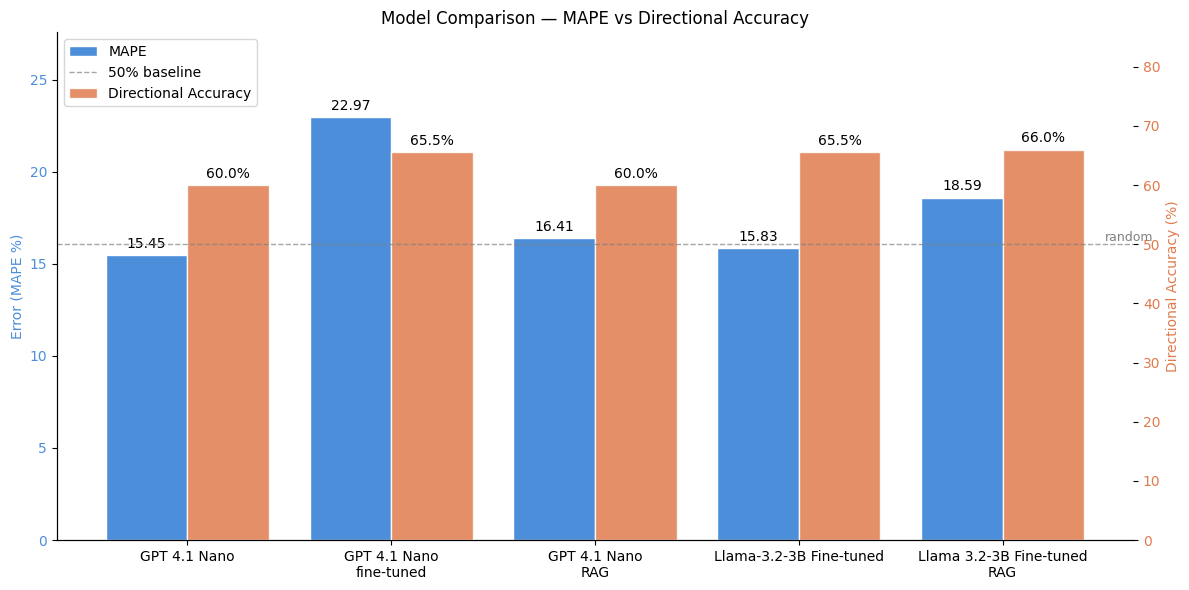

In [20]:
labels = ["GPT 4.1 Nano", "GPT 4.1 Nano\nfine-tuned", "GPT 4.1 Nano\nRAG", "Llama-3.2-3B Fine-tuned", "Llama 3.2-3B Fine-tuned\nRAG"]
values = [15.45, 22.97, 16.41, 15.83, 18.59]
dir_accuracies = [60, 65.5, 60, 65.5, 66]

x = np.arange(len(labels))
width = 0.4

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(x - width/2, values, width, color="#4C8EDA", edgecolor="white", label="MAPE")
ax1.set_ylabel("Error (MAPE %)", color="#4C8EDA")
ax1.tick_params(axis="y", labelcolor="#4C8EDA")
ax1.bar_label(bars, fmt="%.2f", padding=3)
ax1.set_ylim(0, max(values) * 1.2)
ax1.spines[["top", "right"]].set_visible(False)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, dir_accuracies, width, color="#E07B4C", edgecolor="white", label="Directional Accuracy", alpha=0.85)
ax2.set_ylabel("Directional Accuracy (%)", color="#E07B4C")
ax2.tick_params(axis="y", labelcolor="#E07B4C")
ax2.bar_label(bars2, fmt="%.1f%%", padding=3)
ax2.set_ylim(0, max(dir_accuracies) * 1.3)
ax2.spines[["top", "right"]].set_visible(False)

# Add 50% random baseline line on right axis
ax2.axhline(y=50, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="50% baseline")
ax2.text(len(labels) - 0.5, 50.5, "random", color="gray", fontsize=9)

ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title("Model Comparison — MAPE vs Directional Accuracy")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()